           Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models

Step 1: Identify the Business Problem

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.

Likely Business Problem:

The business wants to forecast future milk production to:

•	Ensure proper supply chain and distribution planning.

•	Manage inventory and storage efficiently.

•	Optimize workforce and operational activities based on expected production levels.

•	Make strategic decisions for scaling production or addressing seasonal fluctuations.
________________________________________
Step 2: Define the Objective

Objective Statement:

The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.

Steps to include;
✅ Assignment Tasks

1.	Exploratory Data Analysis (EDA)
o	Visualize trends, seasonality, and anomalies in the milk production data.

o	Check for any missing values or outliers.

o	Normalize or scale the data for neural network models.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [3]:
df = pd.read_csv('monthly_milk_production.csv', index_col='Date', parse_dates=['Date'])
df

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


In [4]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [6]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [7]:
df.columns

Index(['Production'], dtype='object')

In [8]:
df.shape

(168, 1)

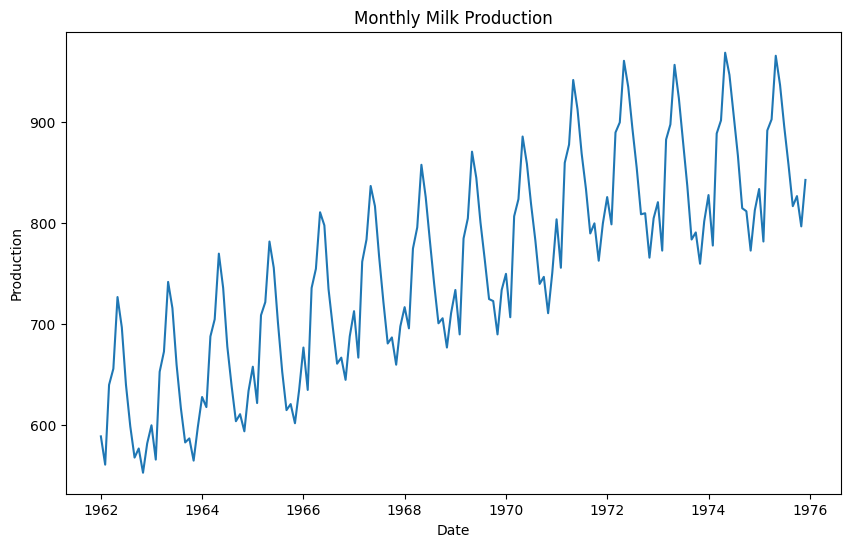

In [9]:
plt.figure(figsize=(10,6))
plt.plot(df)
plt.title('Monthly Milk Production')
plt.xlabel('Date')
plt.ylabel('Production')
plt.show()


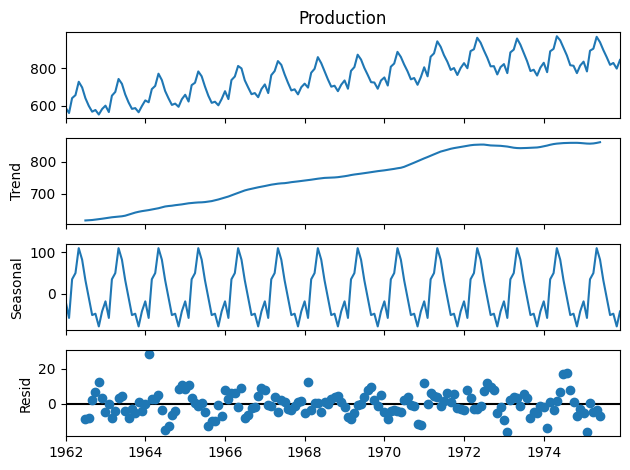

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['Production'], model='additive', period=12)
decomp.plot()
plt.show()

In [12]:
print(df.isnull().sum())

Production    0
dtype: int64


In [13]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)


2.	Data Preparation for Deep Learning

o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.

o	Split data into training, validation, and test sets.

o	Reshape data for model input dimensions.


In [14]:
from sklearn.model_selection import train_test_split
import numpy as np
import warnings
warnings .filterwarnings("ignore")

In [15]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


In [21]:
X_train = X_train.reshape(X_train.shape[0], window_size, 1)
X_test = X_test.reshape(X_test.shape[0], window_size, 1)

In [22]:
window_size = 12
X, y = create_sequences(scaled_data, window_size)

In [23]:
X = X.reshape((X.shape[0], window_size, 1))
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (156, 12, 1), y shape: (156, 1)


In [24]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [25]:
print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Train shapes: X=(124, 12, 1), y=(124, 1)
Validation shapes: X=(16, 12, 1), y=(16, 1)
Test shapes: X=(16, 12, 1), y=(16, 1)


3.	Model Building

o	Build three separate models:

	Basic RNN

	LSTM

	GRU

o	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

o	Use appropriate loss functions and optimizers.


In [28]:
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, GRU, Dense


In [37]:
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, input_shape=(window_size, 1)))
model_rnn.add(Dense(1))
model_rnn.compile(loss='mean_squared_error', optimizer='adam')

In [38]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(window_size, 1)))
model_lstm.add(Dense(1))
model_lstm.compile(loss='mean_squared_error', optimizer='adam')

In [39]:
model_gru = Sequential()
model_gru.add(GRU(50, input_shape=(window_size, 1)))
model_gru.add(Dense(1))
model_gru.compile(loss='mean_squared_error', optimizer='adam')

In [40]:
print("RNN Model:")
model_rnn.summary()
print("\nLSTM Model:")
model_lstm.summary()
print("\nGRU Model:")
model_gru.summary()

RNN Model:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

...

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_rnn.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0015
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0015 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0015
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0015
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0015
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0015 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0015
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0015
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0015
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0014 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0015
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0015
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0014
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0014
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0015
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━

In [43]:
model_lstm.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0171
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0167
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0162
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0161
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0150 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0149
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0139
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0133
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0127
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0118
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0113
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0103
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0097
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0096
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0083
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━

In [44]:
model_gru.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0161
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0159
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0156
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0154
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0151
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0148
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0146
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0144
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0141
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0138
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0135
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0133
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0130
Epoch 14/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0128
Epoch 15/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0125
Epoch 16/50
4/4 ━━━━━━━━━━━━━━━━━━

4.	Model Evaluation 

o	Plot predictions vs. actual values.

o	Calculate forecasting metrics: RMSE, MAE, MAPE.

o	Compare the performance of RNN, LSTM, and GRU.


In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error


In [46]:
y_pred_rnn = model_rnn.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step


In [47]:
y_pred_lstm = model_lstm.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


In [48]:
y_pred_gru = model_gru.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


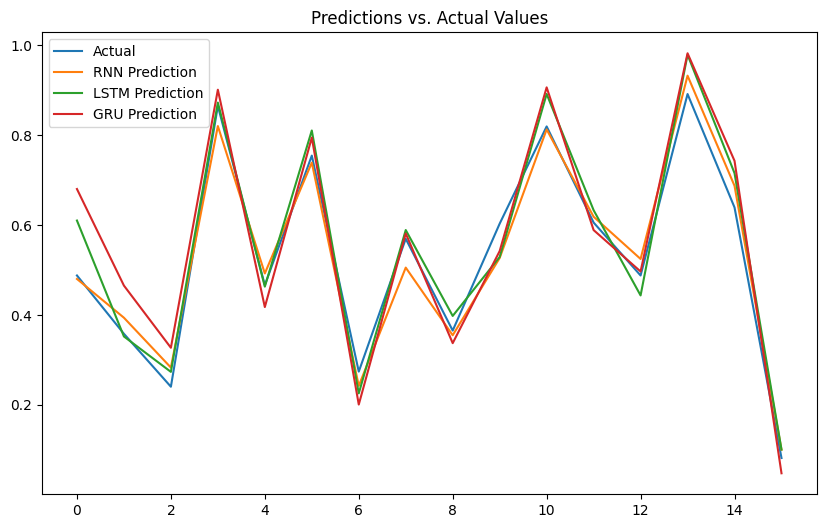

In [49]:
plt.figure(figsize=(10,6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_rnn, label='RNN Prediction')
plt.plot(y_pred_lstm, label='LSTM Prediction')
plt.plot(y_pred_gru, label='GRU Prediction')
plt.legend()
plt.title('Predictions vs. Actual Values')
plt.show()

In [41]:
rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))

In [42]:
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
mae_gru = mean_absolute_error(y_test, y_pred_gru)


In [43]:

mape_rnn = mean_absolute_percentage_error(y_test, y_pred_rnn)
mape_lstm = mean_absolute_percentage_error(y_test, y_pred_lstm)
mape_gru = mean_absolute_percentage_error(y_test, y_pred_gru)


In [44]:

print('RNN: RMSE = {:.2f}, MAE = {:.2f}, MAPE = {:.2f}'.format(rmse_rnn, mae_rnn, mape_rnn))
print('LSTM: RMSE = {:.2f}, MAE = {:.2f}, MAPE = {:.2f}'.format(rmse_lstm, mae_lstm, mape_lstm))
print('GRU: RMSE = {:.2f}, MAE = {:.2f}, MAPE = {:.2f}'.format(rmse_gru, mae_gru, mape_gru))


RNN: RMSE = 0.04, MAE = 0.03, MAPE = 0.07
LSTM: RMSE = 0.05, MAE = 0.04, MAPE = 0.08
GRU: RMSE = 0.06, MAE = 0.05, MAPE = 0.11


5.	Prediction and Visualization

o	Forecast milk production for the next 12 months.

o	Visualize the predicted trend with uncertainty or confidence intervals if possible.


In [48]:
next_12_months = []
input_sequence = X_test[-1].reshape(1, window_size, 1)

for i in range(12):
    # Predict the next value
    next_value = model_lstm.predict(input_sequence)
    
    # Append the prediction to the result list
    next_12_months.append(next_value[0, 0])
    
    # Update the input sequence by removing the first element and adding the new prediction
    input_sequence = np.append(input_sequence[:, 1:, :], next_value.reshape(1, 1, 1), axis=1)

# Convert predictions back to original scale (if scaled)
next_12_months = scaler.inverse_transform(np.array(next_12_months).reshape(-1, 1))

# Plot the forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


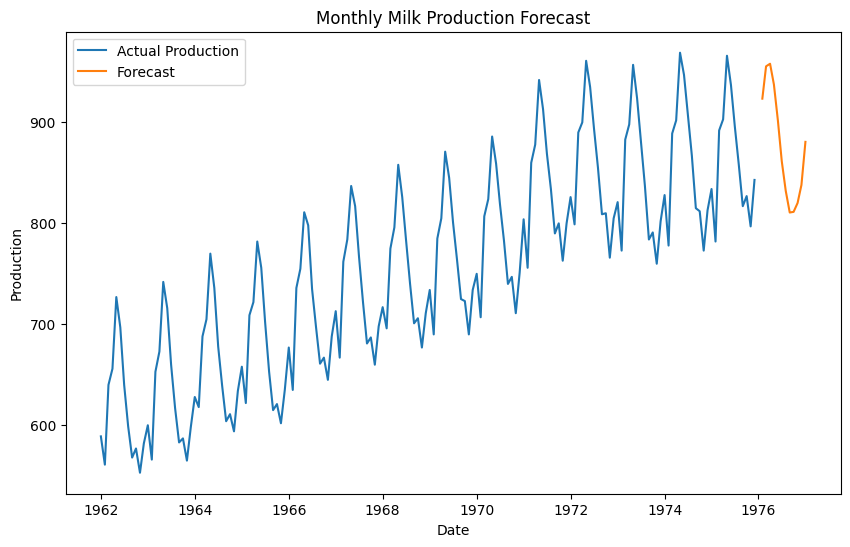

In [50]:
# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(df.index, df.values, label='Actual Production')
plt.plot(pd.date_range(start=df.index[-1], periods=13, freq='M')[1:], next_12_months, label='Forecast')
plt.title('Monthly Milk Production Forecast')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()

6.	Business Insights

o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.



Recommendations for the Dairy Business

1. Supply Chain & Distribution:

    - Align procurement of feed and logistics with predicted production peaks to avoid bottlenecks.

    - Schedule deliveries of raw milk to processing plants based on forecasted volumes.

2. Inventory & Storage:

    - Optimize cold‑storage capacity for months with high production forecasts.

    - Reduce over‑stocking by aligning inventory levels with predicted output.

3. Workforce & Operations:

    - Plan labor allocation (e.g., milking shifts, maintenance) according to expected production loads.

    - Schedule equipment servicing during low‑production periods forecasted by the model.

4. Strategic Decisions:

    - Use forecasts to decide on expansion (e.g., adding cattle or facilities) when consistent growth is predicted.

    - Implement seasonal pricing or marketing strategies aligned with production highs/lows.

5. Risk Management:

    - Set buffer stocks for months with higher forecast uncertainty (use confidence intervals).

    - Monitor anomalies in real‑time to adjust operations promptly.

Actionable Steps- 

- Integrate the LSTM forecast into the ERP system for automated planning.

- Review forecast performance monthly and retrain the model with new data to improve accuracy.

- Combine forecasts with market demand data to optimize production‑to‑sales alignment.
